In [89]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 
from imblearn.combine import SMOTEENN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [90]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [91]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_lieux = []

for year in years:
    df_lieux_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"lieux-{year}.csv"), encoding="utf-8", sep = ";", dtype=str)
    df_lieux.append(df_lieux_year)

df_lieux = pandas.concat(df_lieux)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,1,3,0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000002,1,1,0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70
2,201900000003,1,86,0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90
3,201900000004,1,4,0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90
4,201900000005,1,86,0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70243,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
70244,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
70245,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
70246,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [92]:
column_names_to_int = ['Num_Acc', 'catr', 'v1', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [93]:
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For catr proportion missing: 0.00%
For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For circ proportion missing: 6.00%
For nbv proportion missing: 2.97%
For vosp proportion missing: 2.53%
For prof proportion missing: 0.08%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For plan proportion missing: 0.07%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%
For surf proportion missing: 0.09%
For infra proportion missing: 1.10%
For situ proportion missing: 0.11%
For vma proportion missing: 3.23%


In [94]:
# First we are dropping features that we are not going to use
df_lieux.drop(columns = ['voie', 'v1', 'v2', 'pr', 'pr1', 'lartpc', 'larrout'], inplace = True)


In [95]:
df_lieux["vma"].describe()

count     347911
unique        52
top           50
freq      179006
Name: vma, dtype: int64

In [96]:
df_lieux["vma"].value_counts().sort_index()

vma
0           2
1          88
2          59
3          17
4           5
5         149
6          36
7           3
8           2
9           1
10        658
12          2
15        200
16          1
20       1137
23          1
25        222
30      49801
31          1
35         21
40        360
42          1
45        117
50     179006
55          3
60        898
65          4
70      23949
75          5
80      47971
85          1
90      25332
95          1
100        55
110     11494
120         1
130      6212
140         2
180         1
300         9
301         1
500        62
501         1
502         1
520         1
560         1
600         1
700         5
770         1
800         2
900         6
901         1
Name: count, dtype: int64

In [97]:
df_lieux = df_lieux[(df_lieux['vma'] >= 0) & (df_lieux['vma'] <= 130)]

In [98]:

df_lieux = df_lieux.copy()  # évite SettingWithCopyWarning

df_lieux["vma"] = pandas.to_numeric(df_lieux["vma"], errors="coerce")

df_lieux["vma"] = df_lieux.groupby("catr")["vma"].transform(
    lambda x: x.fillna(x.median()) 
)

In [99]:
imputer = SimpleImputer(strategy="most_frequent")

small_na_cols = df_lieux.columns[(df_lieux.isna().sum() < 50000) & (df_lieux.isna().sum() > 0)]
df_lieux[small_na_cols] = df_lieux[small_na_cols].replace({pandas.NA: np.nan})

df_lieux[small_na_cols ] = imputer.fit_transform(df_lieux[small_na_cols])

In [100]:
df_lieux.columns

Index(['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma'],
      dtype='str')

In [101]:
# And converting to int
column_names_to_int = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', "vma"]

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].astype("int64")

In [102]:
df_lieux["vma"].value_counts().sort_index()

vma
0           2
1          88
2          59
3          17
4           5
5         149
6          36
7           3
8           2
9           1
10        658
12          2
15        200
16          1
20       1137
23          1
25        222
30      49801
31          1
35         21
40        360
42          1
45        117
50     179006
55          3
60        898
65          4
70      23949
75          5
80      47971
85          1
90      25332
95          1
100        55
110     11494
120         1
130      6212
Name: count, dtype: int64

In [103]:
valid_limits = [5,10,15,20,30,50,70,80,90,110,130]
percentage = 1 - (len(df_lieux['vma'][df_lieux['vma'].isin(valid_limits)]) / len(df_lieux['vma']))
print(f"Proportion of speed limit outside valid limits: {percentage * 100 :0.2f}%")

Proportion of speed limit outside valid limits: 0.55%


In [106]:
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_lieux_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_lieux,      
    on='Num_Acc',
    how='left'
)

In [107]:
df_lieux_with_target.dropna()

,Num_Acc,grav_bin,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma
0,201900000001,0,1.0,3.0,10.0,0.0,1.0,2.0,1.0,2.0,1.0,70.0
1,201900000001,0,1.0,3.0,10.0,0.0,1.0,2.0,1.0,2.0,1.0,70.0
2,201900000001,0,1.0,3.0,10.0,0.0,1.0,2.0,1.0,2.0,1.0,70.0
3,201900000002,0,1.0,1.0,2.0,0.0,4.0,2.0,1.0,0.0,1.0,70.0
4,201900000003,0,1.0,3.0,8.0,0.0,1.0,3.0,1.0,0.0,1.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...
792329,202400054401,0,3.0,2.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,50.0
792330,202400054401,0,3.0,2.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,50.0
792331,202400054402,0,3.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,50.0
792332,202400054402,0,3.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,50.0


In [119]:
df = df_lieux_with_target.copy()
df['vma'] = df['vma'].where(~df['vma'].isin(valid_limits), None)
df.dropna(inplace=True)
df['grav_bin'].value_counts()  / len(df) 

grav_bin
0    0.76038
1    0.23962
Name: count, dtype: float64

In [ ]:
df_lieux['vma'] = df_lieux['vma'].where(df_lieux['vma'].isin(valid_limits), None)
df_lieux = df_lieux.dropna()
df_lieux['vma'] = df_lieux['vma'].astype("int64")

In [ ]:
nvb_val = df_lieux["nbv"].unique()
nvb_val.sort()
nvb_val

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [ ]:
percentage_empty = len(df_lieux['nbv'][df_lieux['nbv'] == 0]) / len(df_lieux['nbv'])
print(f"Proportion of empty nbv: {percentage_empty * 100 :0.2f}%")

valid_nbv = [i for i in range(1, 9)]
percentage = 1 - (len(df_lieux['nbv'][df_lieux['nbv'].isin(valid_nbv)]) / len(df_lieux['nbv']))
print(f"Proportion of nbv with extremely large values: {(percentage - percentage_empty) * 100:0.2f}%")

Proportion of empty nbv: 2.74%
Proportion of nbv with extremely large values: 0.32%


In [ ]:
df_lieux['nbv'] = df_lieux['nbv'].where(df_lieux['nbv'].isin(valid_nbv), None)
df_lieux = df_lieux.dropna()
df_lieux['nbv'] = df_lieux['nbv'].astype("int64")

In [ ]:
features = column_names_to_int[:]
numerical_features = ["vma", "nbv"]
categorical_features = list(set(column_names_to_int) - set(numerical_features))

In [ ]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_lieux_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_lieux,
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

In [ ]:
df_lieux_with_target = df_lieux_with_target.dropna()

In [ ]:
df_lieux_analyse = df_lieux_with_target.copy() 

mapping = {
    1: "Motorway",  
    2: "National road",  
    3: "Departmental road",  
    4: "Municipal road",  
    5: "Outside public road network",  
    6: "Public parking area",  
    7: "Urban metropolitan roads",  
    9: "Other"
}
df_lieux_analyse["catr"] = df_lieux_analyse["catr"].replace(mapping)

mapping = {
    1: "One-way",
    2: "Two-way",
    3: "Divided road",
    4: "Variable lanes"
}
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

# nbv - ok

mapping = {
    0: "Not applicable",
    1: "Cycle path",
    2: "Cycle lane",
    3: "Reserved lane"
}
df_lieux_analyse["vosp"] = df_lieux_analyse["vosp"].replace(mapping)

mapping = {
    1: "Flat",  
    2: "Slope",  
    3: "Hilltop",  
    4: "Bottom of hill"
}
df_lieux_analyse["prof"] = df_lieux_analyse["prof"].replace(mapping)

mapping = {
    1: "Straight section",  
    2: "Left curve",  
    3: "Right curve", 
    4: "S-shaped curve"
}
df_lieux_analyse["plan"] = df_lieux_analyse["plan"].replace(mapping)

mapping = {
    1: "Normal",   
    2: "Wet",   
    3: "Puddles",   
    4: "Flooded",   
    5: "Snow-covered",   
    6: "Mud",  
    7: "Icy",   
    8: "Oil or other slippery substance",   
    9: "Other"
}
df_lieux_analyse["surf"] = df_lieux_analyse["surf"].replace(mapping)

mapping = {
    0: "None",   
    1: "Tunnel",  
    2: "Bridge",  
    3: "Ramp or interchange",  
    4: "Railway crossing",  
    5: "Designed intersection",  
    6: "Pedestrian area",  
    7: "Toll area",  
    8: "Roadworks",  
    9: "Other"
}
df_lieux_analyse["infra"] = df_lieux_analyse["infra"].replace(mapping)

mapping = {
    0: "None",
    1: "On roadway",  
    2: "On emergency lane",  
    3: "On shoulder",  
    4: "On sidewalk",  
    5: "On cycle path",  
    6: "On other special lane",  
    8: "Other"
}
df_lieux_analyse["situ"] = df_lieux_analyse["situ"].replace(mapping)

# vma - ok

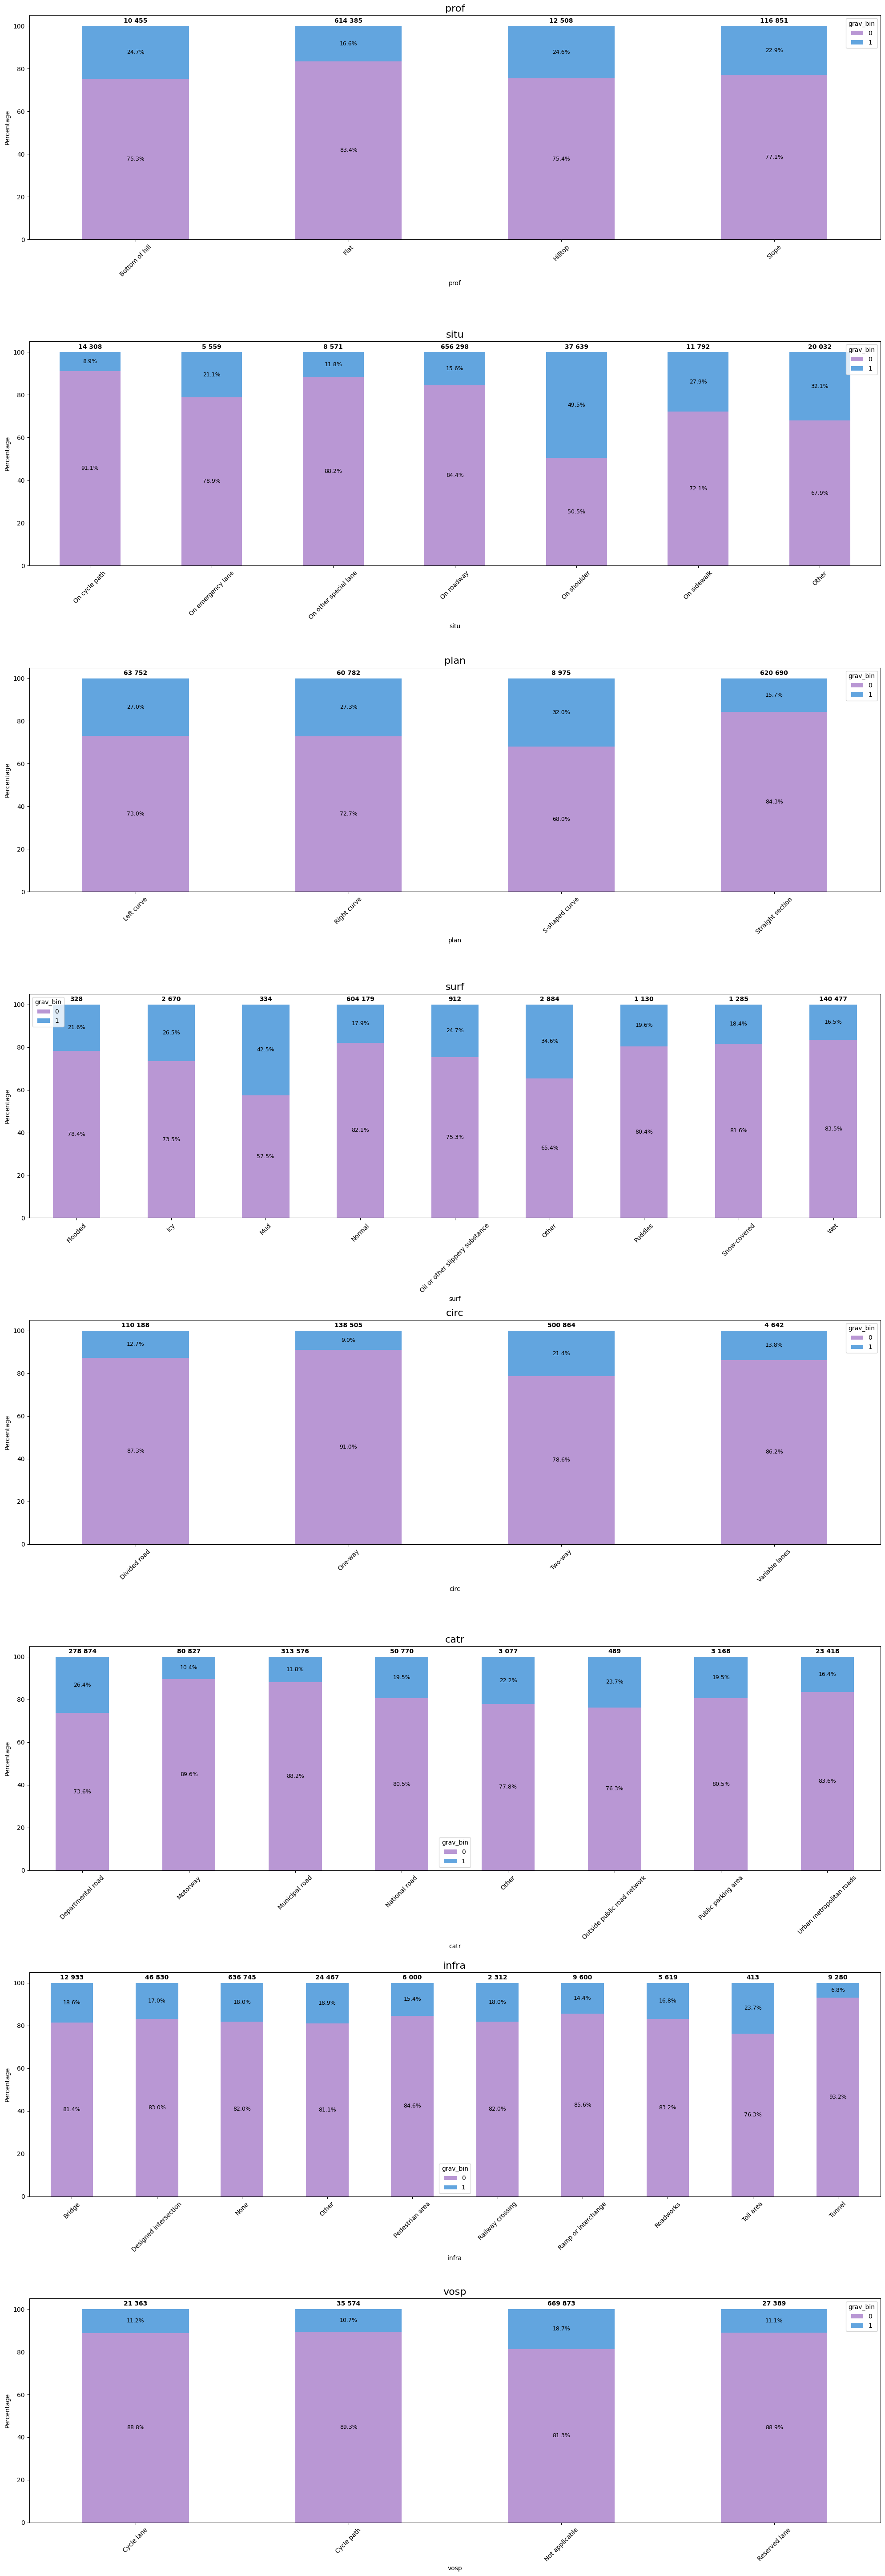

In [ ]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_lieux_analyse = df_lieux_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_lieux_analyse[feature],
        df_lieux_analyse[target],
        normalize="index"
    ) * 100

    counts = df_lieux_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [ ]:
def latex_escape_category(x):
    """
    Convert category labels into LaTeX-safe strings.
    """
    x = str(x)

    # Replace comparison operators with LaTeX math symbols
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    # Escape LaTeX special characters
    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

for feature in features:
    # Count per class
    counts = df_lieux_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    
    # Proportions (in %)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    # Ensure column order (adapt if needed)
    # Assuming: 0 = not severe, 1 = severe
    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        # Replace commas for LaTeX formatting (French style spacing)
        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

# Print result
print("\n".join(output_lines))

\texttt{catr} & Departmental road & 278 874 & 73.6 & 26.4 \\
 & Motorway & 80 827 & 89.6 & 10.4 \\
 & Municipal road & 313 576 & 88.2 & 11.8 \\
 & National road & 50 770 & 80.5 & 19.5 \\
 & Other & 3 077 & 77.8 & 22.2 \\
 & Outside public road network & 489 & 76.3 & 23.7 \\
 & Public parking area & 3 168 & 80.5 & 19.5 \\
 & Urban metropolitan roads & 23 418 & 83.6 & 16.4 \\
\hline
\texttt{circ} & Divided road & 110 188 & 87.3 & 12.7 \\
 & One-way & 138 505 & 91.0 & 9.0 \\
 & Two-way & 500 864 & 78.6 & 21.4 \\
 & Variable lanes & 4 642 & 86.2 & 13.8 \\
\hline
\texttt{nbv} & 1.0 & 78 315 & 87.0 & 13.0 \\
 & 2.0 & 480 616 & 78.3 & 21.7 \\
 & 3.0 & 65 781 & 89.8 & 10.2 \\
 & 4.0 & 88 715 & 88.9 & 11.1 \\
 & 5.0 & 12 284 & 88.2 & 11.8 \\
 & 6.0 & 20 473 & 93.0 & 7.0 \\
 & 7.0 & 2 003 & 92.8 & 7.2 \\
 & 8.0 & 6 012 & 95.8 & 4.2 \\
\hline
\texttt{vosp} & Cycle lane & 21 363 & 88.8 & 11.2 \\
 & Cycle path & 35 574 & 89.3 & 10.7 \\
 & Not applicable & 669 873 & 81.3 & 18.7 \\
 & Reserved lane &

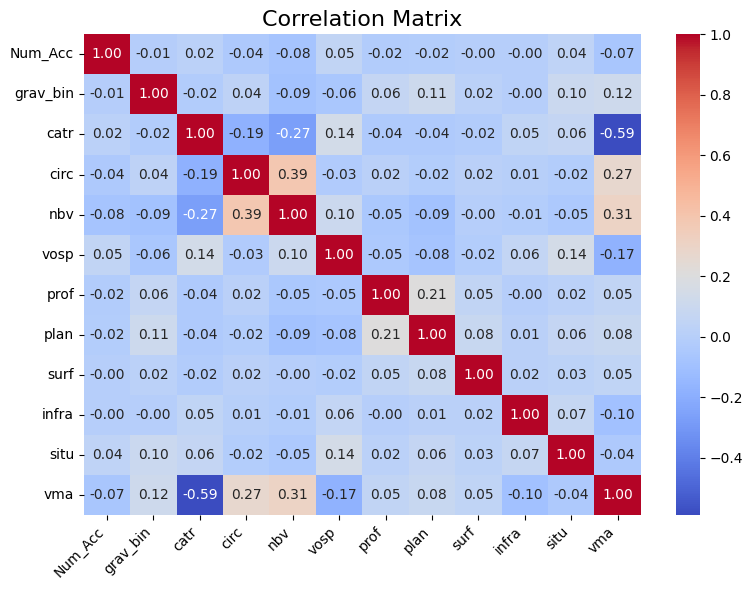

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df_lieux_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
X = df_lieux_with_target[categorical_features + numerical_features]
y = df_lieux_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("over_sampling", RandomOverSampler(random_state=42)),
        ("model", model)
    ])
for name, model in models.items():
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("under_sampling", RandomUnderSampler(random_state=42)),
        ("model", model)
    ])

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec combine-sampling"))


Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.300542120972163
Recall: 0.6432136471990465
F1: 0.4096669928535421
Accuracy: 0.6700505006140622
              precision    recall  f1-score   support

           0       0.90      0.68      0.77    495967
           1       0.30      0.64      0.41    107392

    accuracy                           0.67    603359
   macro avg       0.60      0.66      0.59    603359
weighted avg       0.79      0.67      0.71    603359


 Decision Tree
Precision: 0.3158668919744289
Recall: 0.5778735846245531
F1: 0.4084656293605034
Accuracy: 0.7020911265100876
              precision    recall  f1-score   support

           0       0.89      0.73      0.80    495967
           1       0.32      0.58      0.41    107392

    accuracy                           0.70    603359
   macro avg       0.60      0.65      0.60    603359
weighted avg       0.79      0.70      0.73    603359


 Gradient Boosting
Precision: 0.331346008091634


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))

for name, pipe in pipelines_under.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))


Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.2988801254956643
Recall: 0.6407286314806165
F1: 0.4076187080287633
Accuracy: 0.7162452205071939
              precision    recall  f1-score   support

           0       0.90      0.68      0.77     99262
           1       0.30      0.64      0.41     21410

    accuracy                           0.67    120672
   macro avg       0.60      0.66      0.59    120672
weighted avg       0.79      0.67      0.71    120672


 Decision Tree
Precision: 0.34795748753337025
Recall: 0.6453059318075666
F1: 0.4521238300935925
Accuracy: 0.7162452205071939
              precision    recall  f1-score   support

           0       0.91      0.74      0.81     99262
           1       0.35      0.65      0.45     21410

    accuracy                           0.72    120672
   macro avg       0.63      0.69      0.63    120672
weighted avg       0.81      0.72      0.75    120672


 Gradient Boosting
Precision: 0.33023492539712

In [ ]:
# Finally we are going to save the dataset cleaned
df_lieux.to_csv("df_lieux_clean.csv", index=False)